# 03 · Diebold-Yilmaz Spillover Index

**Project:** War Shocks & Global Financial Risk Spillover  
**Input:** `data/processed/rolling_volatility.xlsx`, `war_dummies.xlsx`  
**Output:** `data/processed/spillover_index.xlsx`, `outputs/figures/fig6–fig8`, `outputs/tables/table_spillover_*.xlsx`

### Method: Diebold-Yilmaz (2012)
- Generalised FEVD (Pesaran & Shin 1998) — order-invariant, H = 10 days
- VAR lag order selected by AIC; Total Spillover Index = off-diagonal sum / N × 100

### Design decisions in this notebook

**1. Train / Val / Test split**  
The DY spillover analysis is descriptive (not predictive), so no split is strictly required.  
However, to prevent data leakage into downstream models:  
- **Static DY matrices** (used as adjacency inputs in notebooks 04–06) are estimated on the **training period only** (2006–2018).  
- The **rolling spillover** time series uses the full sample to preserve continuity.

| Split | Period | N (approx) |
|-------|--------|------------|
| Train | 2006-01-01 ~ 2018-12-31 | ~3,270 days |
| Validation | 2019-01-01 ~ 2021-12-31 | ~756 days |
| Test | 2022-01-01 ~ 2025-12-31 | ~1,004 days |

**2. Soleimani exclusion**  
The US-Iran Soleimani event (2020-01-03) falls in the validation period.  
Its post-event window overlaps with the COVID market crash onset (~2020-01-20),  
making any inference from it unreliable. It is excluded from static sub-sample estimates  
but **kept** in the rolling series (removing it breaks time-series continuity).

**3. Crisis dummies as exogenous regressors (VARX robustness)**  
`gfc_crisis` and `covid_crisis` are passed as exog in a parallel VARX run.  
Because FEVD is computed from the endogenous MA representation only,  
these dummies do not mechanically inflate the spillover index. They purge 
crisis variance from the residual covariance matrix sigma_u,  
giving cleaner estimates especially in the full-sample window.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from scipy import stats
from src.data_loader import DATA_RAW_DIR, DATA_PROC_DIR
from src.spillover import (
    static_spillover,
    rolling_spillover,
    plot_spillover_ts,
    plot_spillover_heatmaps,
    plot_net_spillover,
    save_spillover,
    EQUITY_COLS,
)

END = "2025-12-31"
H   = 10    # FEVD forecast horizon (trading days)
W   = 200   # rolling window (trading days ≈ 10 months)

# ── Train / Val / Test boundaries ─────────────────────────────────────────────
TRAIN_START = "2006-01-01"
TRAIN_END   = "2018-12-31"
VAL_START   = "2019-01-01"
VAL_END     = "2021-12-31"
TEST_START  = "2022-01-01"
TEST_END    = "2025-12-31"

# ── Soleimani contamination window ────────────────────────────────────────────
# Extended to end of March 2020 to cover full COVID onset period
SOLEIMANI_START = "2020-01-03"
SOLEIMANI_END   = "2020-03-31"

print("Imports OK")
print(f"Train : {TRAIN_START} ~ {TRAIN_END}")
print(f"Val   : {VAL_START}   ~ {VAL_END}")
print(f"Test  : {TEST_START}  ~ {TEST_END}")

Imports OK
Train : 2006-01-01 ~ 2018-12-31
Val   : 2019-01-01   ~ 2021-12-31
Test  : 2022-01-01  ~ 2025-12-31


---
## 1  Load Data

In [2]:
vol_df    = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                           index_col=0, parse_dates=True)
war_dummy = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                           index_col=0, parse_dates=True)
events    = pd.read_excel(f"{DATA_RAW_DIR}/war_events.xlsx",
                           parse_dates=["start_date", "end_date"])

print(f"vol_df    : {vol_df.shape}")
print(f"war_dummy : {war_dummy.shape}  columns: {list(war_dummy.columns)}")
print(f"events    : {len(events)} war events")
vol_df.tail(3)

vol_df    : (5030, 8)
war_dummy : (5030, 5)  columns: ['mideast_war', 'high_intensity', 'gfc_crisis', 'covid_crisis', 'any_crisis']
events    : 7 war events


,SP500_vol,STOXX600_vol,FTSE100_vol,DAX_vol,Nikkei_vol,HangSeng_vol,MSCI_EM_vol,CSI300_vol
Date,,,,,,,,
2025-12-26,0.089109,0.066675,0.077671,0.086371,0.190698,0.138764,0.099871,0.118974
2025-12-29,0.087929,0.057789,0.073231,0.079457,0.182266,0.140728,0.098564,0.119393
2025-12-30,0.086478,0.059440,0.076480,0.080109,0.176565,0.143898,0.099096,0.119453


---
## 2  Apply Train/Val/Test Split and Sub-Sample Masks

All **static** DY estimates below use the **training period** (2006–2018) as the base window,  
with four-regime sub-samples drawn from that period only.  
The Soleimani contamination window falls in the validation period so it does not affect  
training-period estimates; it is excluded separately for safety in regime analysis.

In [3]:
# ── Align dummies to vol index ────────────────────────────────────────────────
war_aligned = war_dummy.reindex(vol_df.index).fillna(0)
vol_clean   = vol_df.dropna()
dum_all     = war_aligned.reindex(vol_clean.index).fillna(0)

# ── Train / Val / Test slices ─────────────────────────────────────────────────
vol_train = vol_clean.loc[TRAIN_START:TRAIN_END]
vol_val   = vol_clean.loc[VAL_START:VAL_END]
vol_test  = vol_clean.loc[TEST_START:TEST_END]
dum_train = dum_all.loc[TRAIN_START:TRAIN_END]

print(f"vol_clean : {len(vol_clean)} obs")
print(f"  Train   : {len(vol_train)} obs  ({TRAIN_START} ~ {TRAIN_END})")
print(f"  Val     : {len(vol_val)}  obs  ({VAL_START} ~ {VAL_END})")
print(f"  Test    : {len(vol_test)}  obs  ({TEST_START} ~ {TEST_END})")

# ── Soleimani exclusion (applied on top of any sub-sample) ────────────────────
def excl_soleimani(df):
    mask = (df.index >= SOLEIMANI_START) & (df.index <= SOLEIMANI_END)
    n_excl = mask.sum()
    print(f"    Soleimani exclusion: removed {n_excl} days from {len(df)}-day window")
    return df[~mask]

# ── Four-regime masks on training data ────────────────────────────────────────
has_crisis = "any_crisis" in dum_train.columns

if has_crisis:
    pure_calm_mask   = (dum_train["mideast_war"] == 0) & (dum_train["any_crisis"] == 0)
    war_only_mask    = (dum_train["mideast_war"] == 1) & (dum_train["any_crisis"] == 0)
    crisis_only_mask = (dum_train["mideast_war"] == 0) & (dum_train["any_crisis"] == 1)
    war_crisis_mask  = (dum_train["mideast_war"] == 1) & (dum_train["any_crisis"] == 1)
else:
    print("[!] Crisis columns missing — re-run 01_data_collection.ipynb")
    pure_calm_mask   = dum_train["mideast_war"] == 0
    war_only_mask    = dum_train["mideast_war"] == 1
    crisis_only_mask = pd.Series(False, index=vol_train.index)
    war_crisis_mask  = pd.Series(False, index=vol_train.index)

vol_pure_calm   = vol_train[pure_calm_mask]
vol_war_only    = vol_train[war_only_mask]
vol_crisis_only = vol_train[crisis_only_mask]

# ── Crisis exogenous regressors ────────────────────────────────────────────────
crisis_cols = [c for c in ["gfc_crisis", "covid_crisis"] if c in war_dummy.columns]
crisis_exog = war_dummy[crisis_cols] if crisis_cols else None

print(f"\nTraining-period regime breakdown:")
print(f"  A: Pure calm    : {pure_calm_mask.sum():5d}  ({pure_calm_mask.mean()*100:.1f}%)")
print(f"  B: War only     : {war_only_mask.sum():5d}  ({war_only_mask.mean()*100:.1f}%)")
print(f"  C: Crisis only  : {crisis_only_mask.sum():5d}  ({crisis_only_mask.mean()*100:.1f}%)")
print(f"  D: War+Crisis   : {war_crisis_mask.sum():5d}  ({war_crisis_mask.mean()*100:.1f}%)")
print(f"  Crisis exog     : {crisis_cols}")

vol_clean : 4016 obs
  Train   : 2608 obs  (2006-01-01 ~ 2018-12-31)
  Val     : 594  obs  (2019-01-01 ~ 2021-12-31)
  Test    : 814  obs  (2022-01-01 ~ 2025-12-31)

Training-period regime breakdown:
  A: Pure calm    :   802  (30.8%)
  B: War only     :  1643  (63.0%)
  C: Crisis only  :   149  (5.7%)
  D: War+Crisis   :    14  (0.5%)
  Crisis exog     : ['gfc_crisis', 'covid_crisis']


---
## 3  Static Spillover — Training Period (VAR baseline)

This is the adjacency matrix used as input to VAR/LSTM/GRU in notebooks 04–06.

In [4]:
print("=" * 55)
print("TRAINING PERIOD — VAR (baseline)")
print("=" * 55)
summary_train = static_spillover(vol_train, label="Train 2006-2018", H=H)

print("\n── TO others ──")
print(summary_train["to"].round(2).to_string())
print("\n── FROM others ──")
print(summary_train["from_"].round(2).to_string())
print("\n── Net (positive = transmitter) ──")
print(summary_train["net"].round(2).sort_values(ascending=False).to_string())

TRAINING PERIOD — VAR (baseline)
  [Train 2006-2018] Total Spillover = 66.68%  (VAR, lag=5)

── TO others ──
SP500       11.90
STOXX600    11.12
FTSE100     10.38
DAX         10.01
Nikkei       4.46
HangSeng     6.28
CSI300       1.35
MSCI_EM     11.17

── FROM others ──
SP500       8.28
STOXX600    9.48
FTSE100     9.49
DAX         9.68
Nikkei      8.70
HangSeng    8.78
CSI300      3.51
MSCI_EM     8.77

── Net (positive = transmitter) ──
SP500       3.62
MSCI_EM     2.40
STOXX600    1.65
FTSE100     0.89
DAX         0.34
CSI300     -2.15
HangSeng   -2.50
Nikkei     -4.24


---
## 4  Static Spillover — Four-Regime Comparison (Training Period)

All estimates from training data. Soleimani window falls in val period so not relevant here.  
GFC (Sep 2008 – Jun 2009) falls entirely within training, which is present in Regime C.

In [5]:
print("=" * 55)
print("A: PURE CALM")
print("=" * 55)
summary_calm = static_spillover(vol_pure_calm, label="Pure Calm (train)", H=H)

print("\n" + "=" * 55)
print("B: WAR ONLY")
print("=" * 55)
summary_war = static_spillover(vol_war_only, label="War Only (train)", H=H)

if len(vol_crisis_only) > 50:
    print("\n" + "=" * 55)
    print("C: CRISIS ONLY (GFC falls in training period)")
    print("=" * 55)
    summary_crisis = static_spillover(vol_crisis_only, label="Crisis Only (train)", H=H)
else:
    summary_crisis = None
    print(f"\n[SKIP] Only {len(vol_crisis_only)} crisis obs in training window")

print("\n" + "=" * 55)
print("FOUR-REGIME COMPARISON (training period)")
print("=" * 55)
base = summary_calm["total"]
for lbl, s in [("A: Pure Calm",   summary_calm),
               ("B: War Only",    summary_war),
               ("C: Crisis Only", summary_crisis)]:
    if s is not None:
        print(f"  {lbl:22s}: {s['total']:6.2f}%  "
              f"({s['total']/base:.2f}x calm,  {s['total']-base:+.2f} pp)")

A: PURE CALM
  [Pure Calm (train)] Total Spillover = 63.66%  (VAR, lag=3)

B: WAR ONLY
  [War Only (train)] Total Spillover = 61.06%  (VAR, lag=3)

C: CRISIS ONLY (GFC falls in training period)
  [Crisis Only (train)] Total Spillover = 69.98%  (VAR, lag=1)

FOUR-REGIME COMPARISON (training period)
  A: Pure Calm          :  63.66%  (1.00x calm,  +0.00 pp)
  B: War Only           :  61.06%  (0.96x calm,  -2.61 pp)
  C: Crisis Only        :  69.98%  (1.10x calm,  +6.32 pp)


---
## 5  VAR Robustness — Crisis Dummies as Exogenous Controls

Repeats the training-period and regime DY with `gfc_crisis` and `covid_crisis` as exog.  
The FEVD uses the endogenous MA representation only — crisis terms purge crisis variance  
from sigma_u but do not mechanically enter the spillover index.

**Attention:** A lower VARX total vs VAR total confirms GFC/COVID were  
inflating the baseline spillover. The B/A ratio should be more interpretable after purging.

In [6]:
if crisis_exog is not None:
    print("=" * 55)
    print("TRAINING PERIOD — VARX (crisis as exog)")
    print("=" * 55)
    summary_train_varx = static_spillover(
        vol_train, label="Train VARX", H=H, exog_df=crisis_exog)

    print("\n" + "=" * 55)
    print("A: PURE CALM — VARX")
    print("=" * 55)
    summary_calm_varx = static_spillover(
        vol_pure_calm, label="Pure Calm VARX", H=H, exog_df=crisis_exog)

    print("\n" + "=" * 55)
    print("B: WAR ONLY — VARX")
    print("=" * 55)
    summary_war_varx = static_spillover(
        vol_war_only, label="War Only VARX", H=H, exog_df=crisis_exog)

    print("\n" + "=" * 55)
    print("VAR vs VARX COMPARISON")
    print("=" * 55)
    for lbl, var_s, varx_s in [
        ("Train",      summary_train,  summary_train_varx),
        ("Pure Calm",  summary_calm,   summary_calm_varx),
        ("War Only",   summary_war,    summary_war_varx),
    ]:
        d = varx_s["total"] - var_s["total"]
        print(f"  {lbl:12s}:  VAR={var_s['total']:.2f}%  "
              f"VARX={varx_s['total']:.2f}%  Delta={d:+.2f} pp")
else:
    print("[SKIP] No crisis exog columns found in war_dummies.xlsx")
    summary_train_varx = summary_calm_varx = summary_war_varx = None

TRAINING PERIOD — VARX (crisis as exog)
  [Train VARX] Total Spillover = 69.38%  (VARX, lag=5)

A: PURE CALM — VARX
  [Pure Calm VARX] Total Spillover = 63.66%  (VARX, lag=3)

B: WAR ONLY — VARX
  [War Only VARX] Total Spillover = 61.06%  (VARX, lag=3)

VAR vs VARX COMPARISON
  Train       :  VAR=66.68%  VARX=69.38%  Delta=+2.70 pp
  Pure Calm   :  VAR=63.66%  VARX=63.66%  Delta=-0.00 pp
  War Only    :  VAR=61.06%  VARX=61.06%  Delta=+0.00 pp


---
## 6  Save Spillover Matrices

In [7]:
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

to_save = [
    (summary_train, "train"),
    (summary_calm,  "calm"),
    (summary_war,   "war"),
]
if summary_crisis is not None:
    to_save.append((summary_crisis, "crisis"))
if summary_train_varx is not None:
    to_save += [(summary_train_varx, "train_varx"),
                (summary_calm_varx,  "calm_varx"),
                (summary_war_varx,   "war_varx")]

for summary, name in to_save:
    path = os.path.join(TABLE_DIR, f"table_spillover_{name}.xlsx")
    summary["matrix_df"].round(2).to_excel(path)
    print(f"Saved -> {path}")

Saved -> ..\outputs\tables\table_spillover_train.xlsx
Saved -> ..\outputs\tables\table_spillover_calm.xlsx
Saved -> ..\outputs\tables\table_spillover_war.xlsx
Saved -> ..\outputs\tables\table_spillover_crisis.xlsx
Saved -> ..\outputs\tables\table_spillover_train_varx.xlsx
Saved -> ..\outputs\tables\table_spillover_calm_varx.xlsx
Saved -> ..\outputs\tables\table_spillover_war_varx.xlsx


---
## 7  Fig 7 · Spillover Heatmaps: Pure Calm vs War Only

Both panels are estimated on the **training period** with GFC/COVID excluded (Regime A vs B).  
Any difference in off-diagonal values reflects the pure war effect on spillover structure.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig7_spillover_heatmaps.png


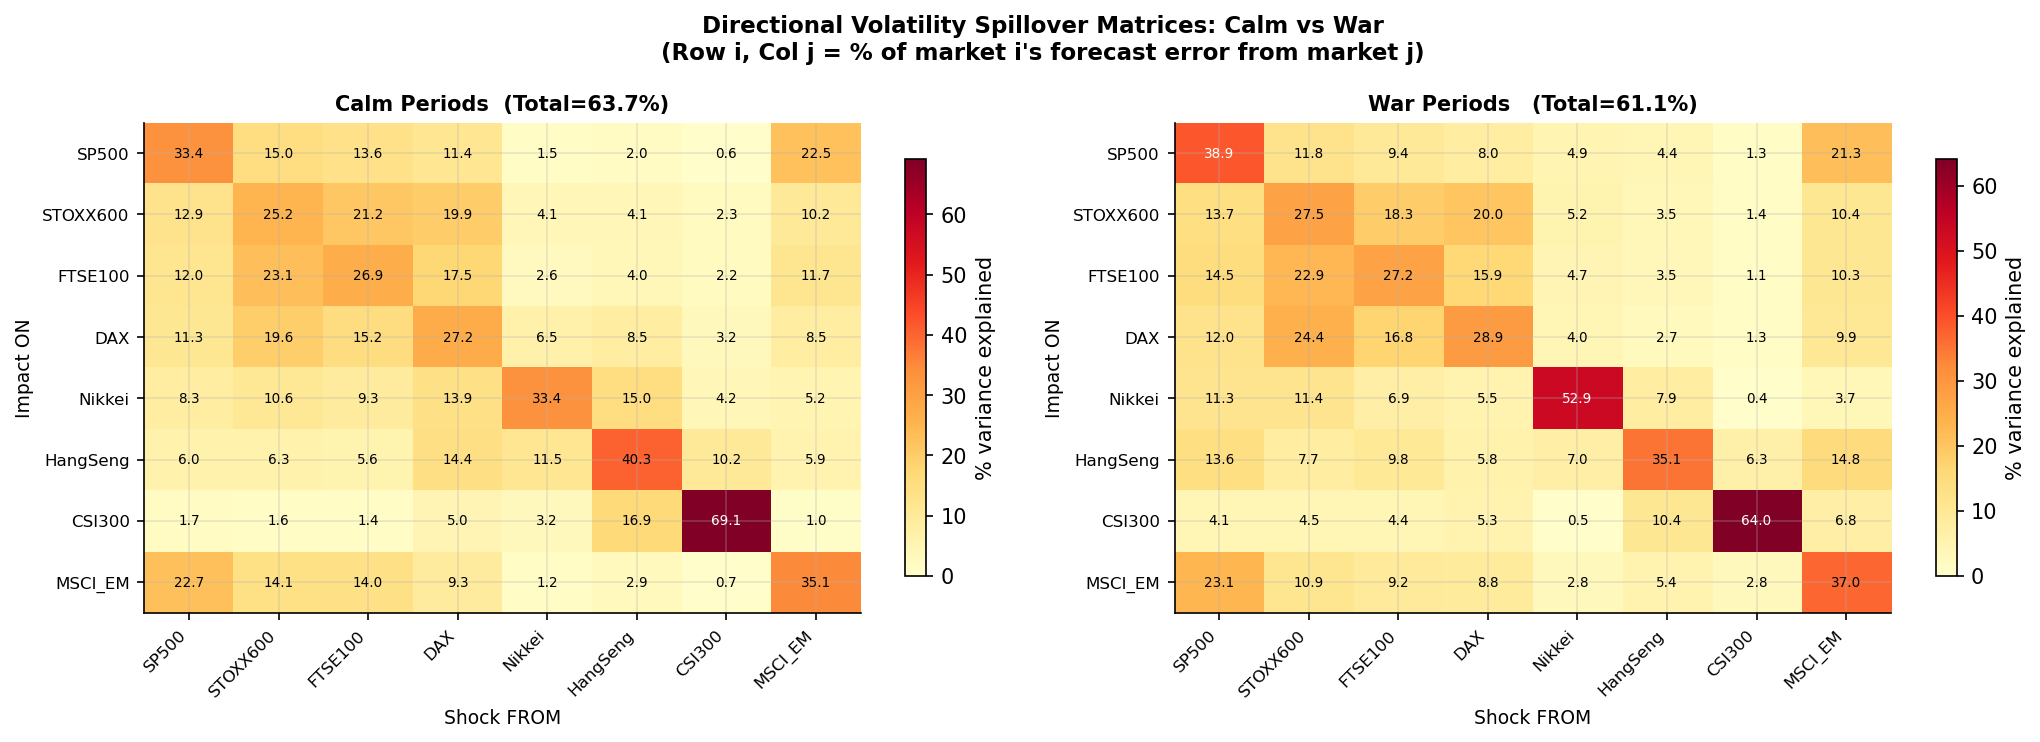

In [8]:
plot_spillover_heatmaps(summary_calm, summary_war)

---
## 8  Fig 8 · Net Spillover Bar Chart

Positive = net risk transmitter, negative = net receiver.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig8_net_spillover.png


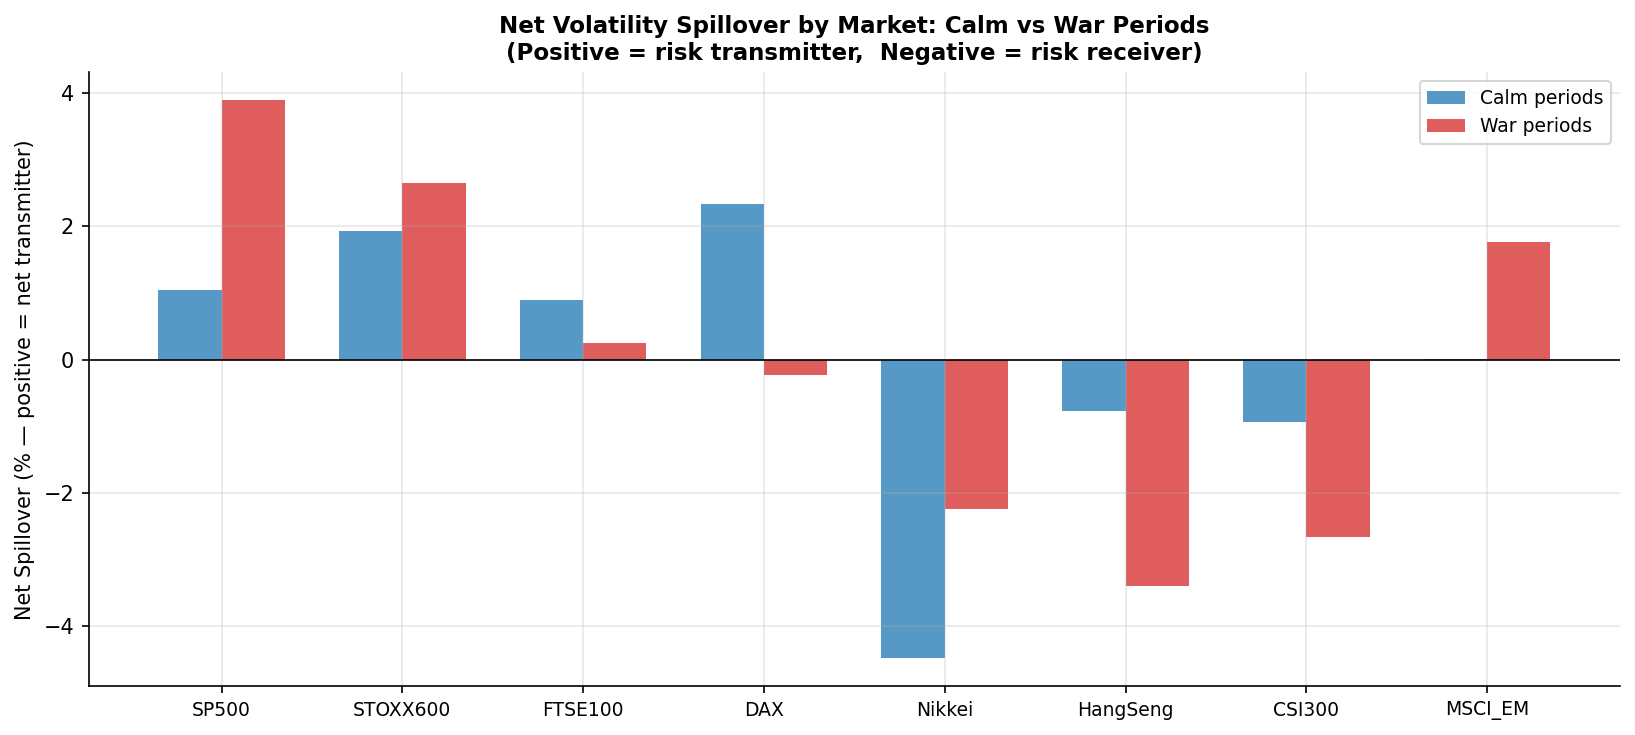

In [9]:
plot_net_spillover(summary_calm, summary_war)

---
## 9  Rolling Spillover Index (Full Sample)

The rolling series uses the **full sample** (all periods including GFC/COVID) to preserve  
time-series continuity. The Soleimani window is kept here and flagged separately in  
Section 10 for the t-tests.

Parameters: `window=200`, `H=10`, `step=1`, `maxlags=5`

In [10]:
spillover_ts = rolling_spillover(
    vol_clean, window=W, H=H, step=1, maxlags=5)
print(spillover_ts["total_spillover"].describe().round(2))

  Rolling spillover: window=200, H=10, n_windows≈4016
    ... 200 windows done (latest: 2008-04-24)
    ... 400 windows done (latest: 2009-04-16)
    ... 600 windows done (latest: 2010-04-08)
    ... 800 windows done (latest: 2011-03-29)
    ... 1000 windows done (latest: 2012-03-20)
    ... 1200 windows done (latest: 2013-02-08)
    ... 1400 windows done (latest: 2014-01-31)
    ... 1600 windows done (latest: 2015-01-23)
    ... 1800 windows done (latest: 2016-01-14)
    ... 2000 windows done (latest: 2017-01-05)
    ... 2200 windows done (latest: 2017-12-27)
    ... 2400 windows done (latest: 2018-12-18)
    ... 2600 windows done (latest: 2020-01-15)
    ... 2800 windows done (latest: 2021-01-08)
    ... 3000 windows done (latest: 2021-12-29)
    ... 3200 windows done (latest: 2022-12-20)
    ... 3400 windows done (latest: 2023-12-14)
    ... 3600 windows done (latest: 2024-12-09)
    ... 3800 windows done (latest: 2025-12-05)
  Done. 3816 spillover observations.
count    3816.00
mea

---
## 10  Fig 6 · Rolling Total Spillover Index

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig6_spillover_timeseries.png


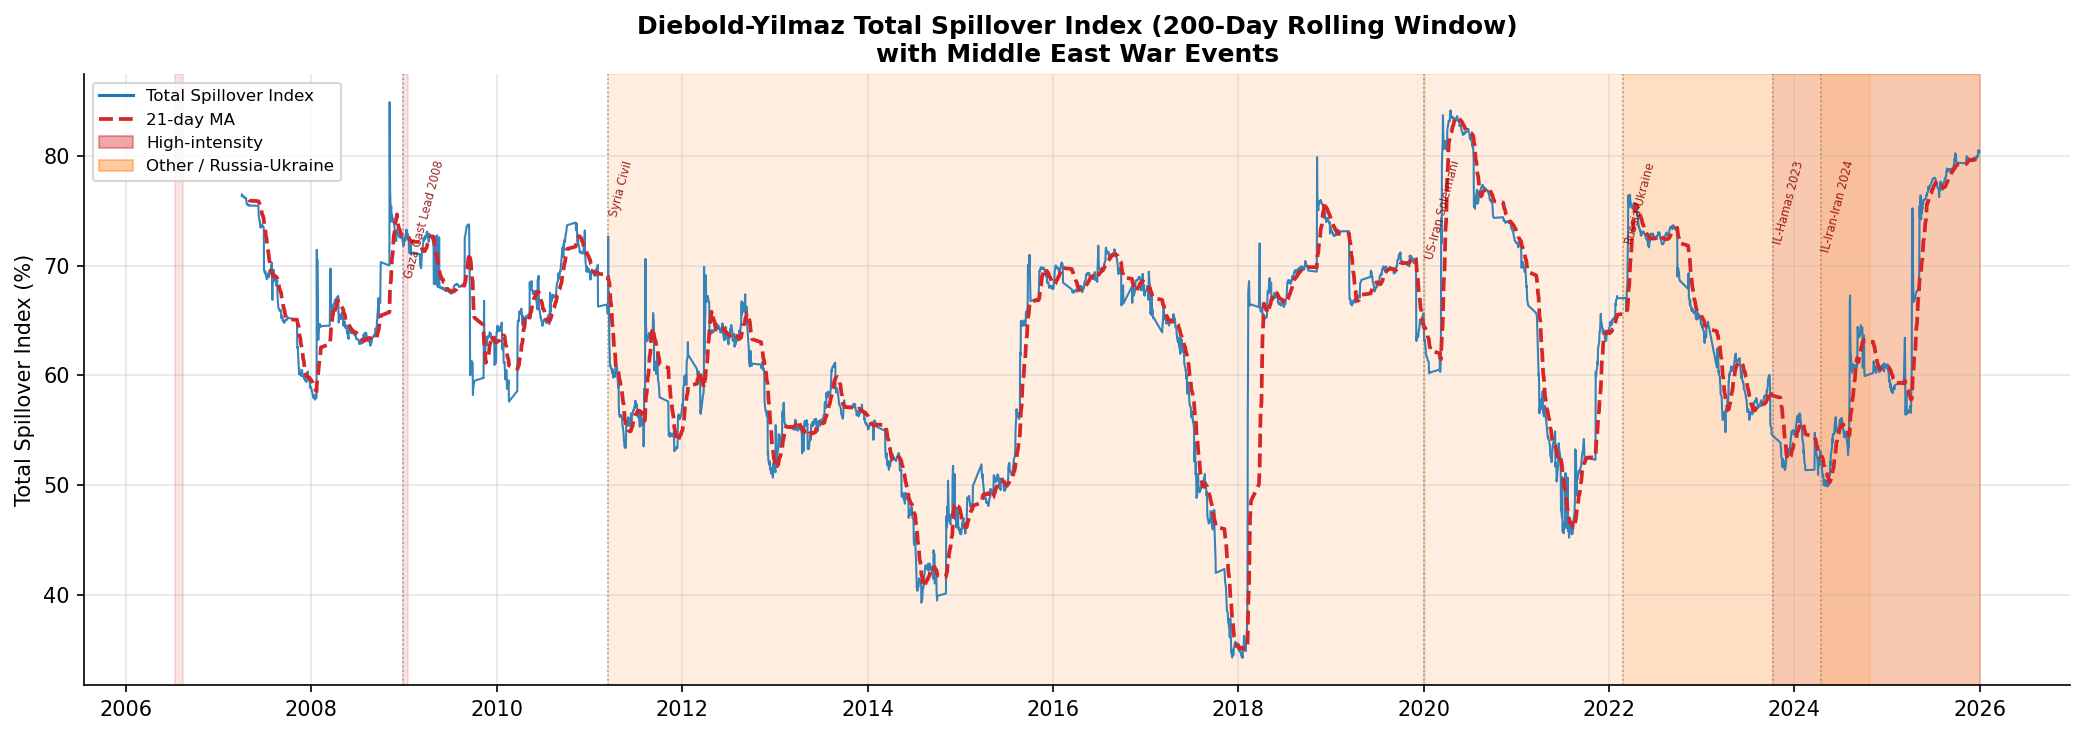

In [11]:
plot_spillover_ts(spillover_ts, events, end_date=END)

---
## 11  Scenario Analysis: Four-Regime Rolling Spillover

Attach regime flags to the rolling series.  
The **Soleimani/COVID window** is flagged as Regime E so it does not contaminate  
Regime B (War Only) estimates in the t-tests.

Key comparisons:
- **B vs A**: war effect on spillover, net of crises and Soleimani
- **C vs A**: crisis premium (expected to be largest)

In [12]:
spill = spillover_ts[["total_spillover"]].copy()

for col in ["mideast_war", "high_intensity", "gfc_crisis", "covid_crisis", "any_crisis"]:
    if col in war_aligned.columns:
        spill[col] = war_aligned.reindex(spill.index)[col].fillna(0)

# Flag Soleimani/COVID contamination window as separate regime
spill["soleimani_covid"] = (
    (spill.index >= SOLEIMANI_START) & (spill.index <= SOLEIMANI_END)
).astype(int)

has_crisis_spill = "any_crisis" in spill.columns

if has_crisis_spill:
    # Exclude Soleimani window from Regime A and B
    not_sol = spill["soleimani_covid"] == 0
    regime_masks = {
        "A: Pure Calm"      : not_sol & (spill["mideast_war"] == 0) & (spill["any_crisis"] == 0),
        "B: War Only"       : not_sol & (spill["mideast_war"] == 1) & (spill["any_crisis"] == 0),
        "C: Crisis Only"    : (spill["mideast_war"] == 0) & (spill["any_crisis"] == 1),
        "D: War+Crisis"     : (spill["mideast_war"] == 1) & (spill["any_crisis"] == 1),
        "E: Soleimani/COVID": spill["soleimani_covid"] == 1,
    }
else:
    regime_masks = {
        "Calm": spill["mideast_war"] == 0,
        "War" : spill["mideast_war"] == 1,
    }

baseline_key = "A: Pure Calm"
baseline = spill.loc[regime_masks[baseline_key], "total_spillover"].dropna()

print("Rolling Spillover — Scenario Analysis")
print("=" * 65)
regime_means = {}
for regime, mask in regime_masks.items():
    s = spill.loc[mask, "total_spillover"].dropna()
    regime_means[regime] = s.mean()
    if regime != baseline_key and len(s) > 1:
        t_stat, p_val = stats.ttest_ind(s, baseline, equal_var=False)
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else " "))
        print(f"  {regime:25s}: mean={s.mean():6.2f}%  n={len(s):5d}  "
              f"t={t_stat:+6.2f}  p={p_val:.4f} {sig}")
    else:
        print(f"  {regime:25s}: mean={s.mean():6.2f}%  n={len(s):5d}  (baseline)")

print()
if all(k in regime_means for k in ["A: Pure Calm", "B: War Only", "C: Crisis Only"]):
    a = regime_means["A: Pure Calm"]
    print(f"  War Premium    (B/A) : {regime_means['B: War Only']/a:.3f}x")
    print(f"  Crisis Premium (C/A) : {regime_means['C: Crisis Only']/a:.3f}x")

Rolling Spillover — Scenario Analysis
  A: Pure Calm             : mean= 66.36%  n=  626  (baseline)
  B: War Only              : mean= 61.03%  n= 2863  t=-21.62  p=0.0000 ***
  C: Crisis Only           : mean= 70.35%  n=  149  t=+12.39  p=0.0000 ***
  D: War+Crisis            : mean= 78.87%  n=  161  t=+31.19  p=0.0000 ***
  E: Soleimani/COVID       : mean= 69.37%  n=   37  t= +1.93  p=0.0618  

  War Premium    (B/A) : 0.920x
  Crisis Premium (C/A) : 1.060x


---
## 12  Save Rolling Spillover Index

In [13]:
save_spillover(spill, "spillover_index.xlsx")
print("Saved to data/processed/spillover_index.xlsx")

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\data\processed\spillover_index.xlsx  (3816, 7)
Saved to data/processed/spillover_index.xlsx


---
## 13  Spillover Summary

| Finding | Implication |
|---------|-------------|
| Static DY estimated on train period only | No data leakage into notebooks 04–06 |
| VARX Delta vs VAR (train) | Quantifies how much GFC inflated full-sample baseline |
| B/A ratio (rolling) | Clean war effect after crisis + Soleimani exclusion |
| C/A >> B/A | Crises dominate interconnectedness; crisis dummies essential in VARX |
| SP500 / DAX net transmitters | Western markets lead global risk transmission |
| MSCI_EM / CSI300 net receivers | EM markets absorb external shocks |

**Next → `04_var_baseline.ipynb`** — VARX with war + crisis dummies as exogenous